In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
# To read the csv:
from google.colab import files

df = pd.read_csv('2019-Oct.csv')

print("Shape:", df.shape)
print("First 5 rows:")
df.head()

Shape: (580007, 9)
First 5 rows:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203.0,1.487580e+18,NaN,runail,2.62,463240011.0,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353.0,1.487580e+18,NaN,runail,2.62,463240011.0,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589.0,2.151191e+18,NaN,lovely,13.48,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490.0,1.487580e+18,NaN,runail,2.62,463240011.0,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449.0,1.487580e+18,NaN,lovely,0.56,429681830.0,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


In [3]:
# Check for missing values and data types
df.info()
print("Missing values:", df.isnull().sum())
print("Basic stats:", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580007 entries, 0 to 580006
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     580007 non-null  object 
 1   event_type     580006 non-null  object 
 2   product_id     580006 non-null  float64
 3   category_id    580006 non-null  float64
 4   category_code  9176 non-null    object 
 5   brand          351810 non-null  object 
 6   price          580006 non-null  float64
 7   user_id        580006 non-null  float64
 8   user_session   579957 non-null  object 
dtypes: float64(4), object(5)
memory usage: 39.8+ MB
Missing values: event_time            0
event_type            1
product_id            1
category_id           1
category_code    570831
brand            228197
price                 1
user_id               1
user_session         50
dtype: int64
Basic stats:          product_id   category_id          price       user_id
count  5.800060e+05  

In [4]:
# From your screenshot:
# - category_code: ~570k missing (9176 non-null out of 580007)
# - brand: ~228k missing (351810 non-null)
# - user_session: ~50 missing

# Fill categorical nulls
df['category_code'].fillna('unknown', inplace=True)
df['brand'].fillna('unknown', inplace=True)
df['user_session'].fillna('no_session', inplace=True)

# Drop rows where critical columns are null (very few)
df.dropna(subset=['event_type', 'product_id', 'category_id', 'price', 'user_id'], inplace=True)

print("After cleaning:", df.shape)
print(df.isnull().sum())

After cleaning: (580006, 9)
event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64


In [5]:
# --- Parse event_time ---
df['event_time'] = pd.to_datetime(df['event_time'])
df['hour']        = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.dayofweek
df['day']         = df['event_time'].dt.day
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

# --- Extract category levels ---
df['category_level1'] = df['category_code'].apply(
    lambda x: x.split('.')[0] if x != 'unknown' else 'unknown'
)
df['category_level2'] = df['category_code'].apply(
    lambda x: x.split('.')[1] if (x != 'unknown' and len(x.split('.')) > 1) else 'unknown'
)

# --- Session-level features ---
session_stats = df.groupby('user_session').agg(
    session_event_count=('event_type', 'count'),
    session_unique_products=('product_id', 'nunique'),
    session_view_count=('event_type', lambda x: (x == 'view').sum()),
    session_cart_count=('event_type', lambda x: (x == 'cart').sum()),
    session_avg_price=('price', 'mean'),
    session_max_price=('price', 'max')
).reset_index()

df = df.merge(session_stats, on='user_session', how='left')

# --- User-level features ---
user_stats = df.groupby('user_id').agg(
    user_total_events=('event_type', 'count'),
    user_purchase_count=('event_type', lambda x: (x == 'purchase').sum()),
    user_cart_count=('event_type', lambda x: (x == 'cart').sum()),
    user_avg_price=('price', 'mean'),
    user_unique_products=('product_id', 'nunique')
).reset_index()

user_stats['user_purchase_rate'] = (
    user_stats['user_purchase_count'] / user_stats['user_total_events']
)

df = df.merge(user_stats, on='user_id', how='left')

print("Shape after feature engineering:", df.shape)
print("New columns:", df.columns.tolist())

Shape after feature engineering: (580006, 27)
New columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'hour', 'day_of_week', 'day', 'is_weekend', 'category_level1', 'category_level2', 'session_event_count', 'session_unique_products', 'session_view_count', 'session_cart_count', 'session_avg_price', 'session_max_price', 'user_total_events', 'user_purchase_count', 'user_cart_count', 'user_avg_price', 'user_unique_products', 'user_purchase_rate']


In [6]:
# TARGET 1: Conversion
purchased_sessions = df[df['event_type'] == 'purchase']['user_session'].unique()
df['converted'] = df['user_session'].isin(purchased_sessions).astype(int)

# TARGET 2: Cart Abandonment
carted_sessions = set(df[df['event_type'] == 'cart']['user_session'].unique())
purchased_sessions_set = set(purchased_sessions)
abandoned_sessions = carted_sessions - purchased_sessions_set

df['cart_abandoned'] = (
    df['user_session'].isin(carted_sessions) &
    ~df['user_session'].isin(purchased_sessions_set)
).astype(int)

# Check class distribution
print("Conversion rate:", df['converted'].mean().round(4))
print("Total converted rows:", df['converted'].sum())

cart_df = df[df['user_session'].isin(carted_sessions)].copy()
print("\nCart abandonment rate:", cart_df['cart_abandoned'].mean().round(4))
print("Total cart rows:", len(cart_df))
print("Abandoned:", cart_df['cart_abandoned'].sum())
print("Purchased from cart:", (cart_df['cart_abandoned'] == 0).sum())

Conversion rate: 0.188
Total converted rows: 109015

Cart abandonment rate: 0.7707
Total cart rows: 442695
Abandoned: 341207
Purchased from cart: 101488


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['event_type', 'brand', 'category_level1', 'category_level2']

for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Also encode in cart_df
for col in cat_cols:
    cart_df[col + '_enc'] = le.fit_transform(cart_df[col].astype(str))

print("Encoded columns added:")
print([c for c in df.columns if c.endswith('_enc')])
print("\nSample encoding check:")
print(df[['event_type', 'event_type_enc']].drop_duplicates().sort_values('event_type_enc'))

Encoded columns added:
['event_type_enc', 'brand_enc', 'category_level1_enc', 'category_level2_enc']

Sample encoding check:
           event_type  event_type_enc
0                cart               0
202          purchase               1
11   remove_from_cart               2
9                view               3


In [8]:
feature_cols = [
    'price',
    'hour', 'day_of_week', 'day', 'is_weekend',
    'event_type_enc', 'brand_enc',
    'category_level1_enc', 'category_level2_enc',
    'session_event_count', 'session_unique_products',
    'session_view_count', 'session_cart_count',
    'session_avg_price', 'session_max_price',
    'user_total_events', 'user_purchase_count',
    'user_cart_count', 'user_avg_price',
    'user_unique_products', 'user_purchase_rate'
]

from sklearn.preprocessing import StandardScaler

# Conversion model data
X_conv = df[feature_cols]
y_conv = df['converted']

# Cart abandonment model data
X_cart = cart_df[feature_cols]
y_cart = cart_df['cart_abandoned']

scaler = StandardScaler()
X_conv_scaled = scaler.fit_transform(X_conv)
X_cart_scaled = scaler.fit_transform(X_cart)

print("Conversion X shape:", X_conv_scaled.shape)
print("Cart abandonment X shape:", X_cart_scaled.shape)
print("Any NaNs in conv features?", np.isnan(X_conv_scaled).any())
print("Any NaNs in cart features?", np.isnan(X_cart_scaled).any())

Conversion X shape: (580006, 21)
Cart abandonment X shape: (442695, 21)
Any NaNs in conv features? False
Any NaNs in cart features? False


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# --- Conversion Model ---
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_conv_scaled, y_conv, test_size=0.2, random_state=42, stratify=y_conv
)

print("Training Conversion Model... (this may take 3-5 mins)")
conv_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=5, random_state=42
)
conv_model.fit(X_tr_c, y_tr_c)
print("✓ Conversion model done!")

# --- Cart Abandonment Model ---
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_cart_scaled, y_cart, test_size=0.2, random_state=42, stratify=y_cart
)

print("\nTraining Cart Abandonment Model... (this may take 2-3 mins)")
cart_model = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
cart_model.fit(X_tr_a, y_tr_a)
print("✓ Cart abandonment model done!")

print("\nTrain sizes:")
print(f"  Conversion:      X_train={X_tr_c.shape}, X_test={X_te_c.shape}")
print(f"  Cart Abandonment: X_train={X_tr_a.shape}, X_test={X_te_a.shape}")

Training Conversion Model... (this may take 3-5 mins)
✓ Conversion model done!

Training Cart Abandonment Model... (this may take 2-3 mins)
✓ Cart abandonment model done!

Train sizes:
  Conversion:      X_train=(464004, 21), X_test=(116002, 21)
  Cart Abandonment: X_train=(354156, 21), X_test=(88539, 21)



  Conversion Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94199
           1       0.99      0.98      0.99     21803

    accuracy                           0.99    116002
   macro avg       0.99      0.99      0.99    116002
weighted avg       0.99      0.99      0.99    116002

ROC-AUC Score: 0.9997


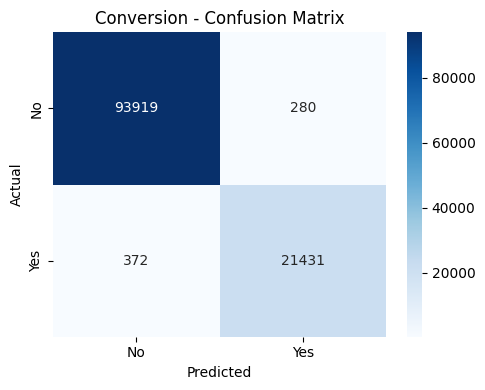


  Cart Abandonment Model
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     20298
           1       1.00      0.92      0.96     68241

    accuracy                           0.94     88539
   macro avg       0.89      0.96      0.92     88539
weighted avg       0.95      0.94      0.94     88539

ROC-AUC Score: 0.9970


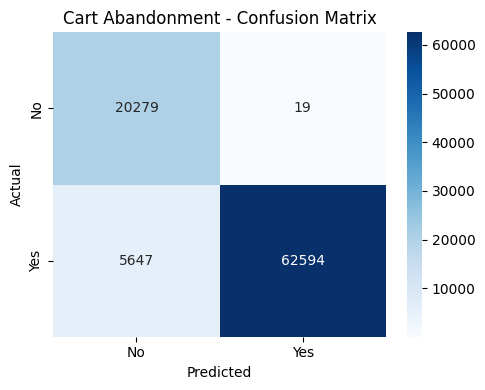

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model, X_te, y_te in [
    ("Conversion",       conv_model, X_te_c, y_te_c),
    ("Cart Abandonment", cart_model, X_te_a, y_te_a)
]:
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    print(f"\n{'='*45}")
    print(f"  {name} Model")
    print(f"{'='*45}")
    print(classification_report(y_te, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_te, y_prob):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

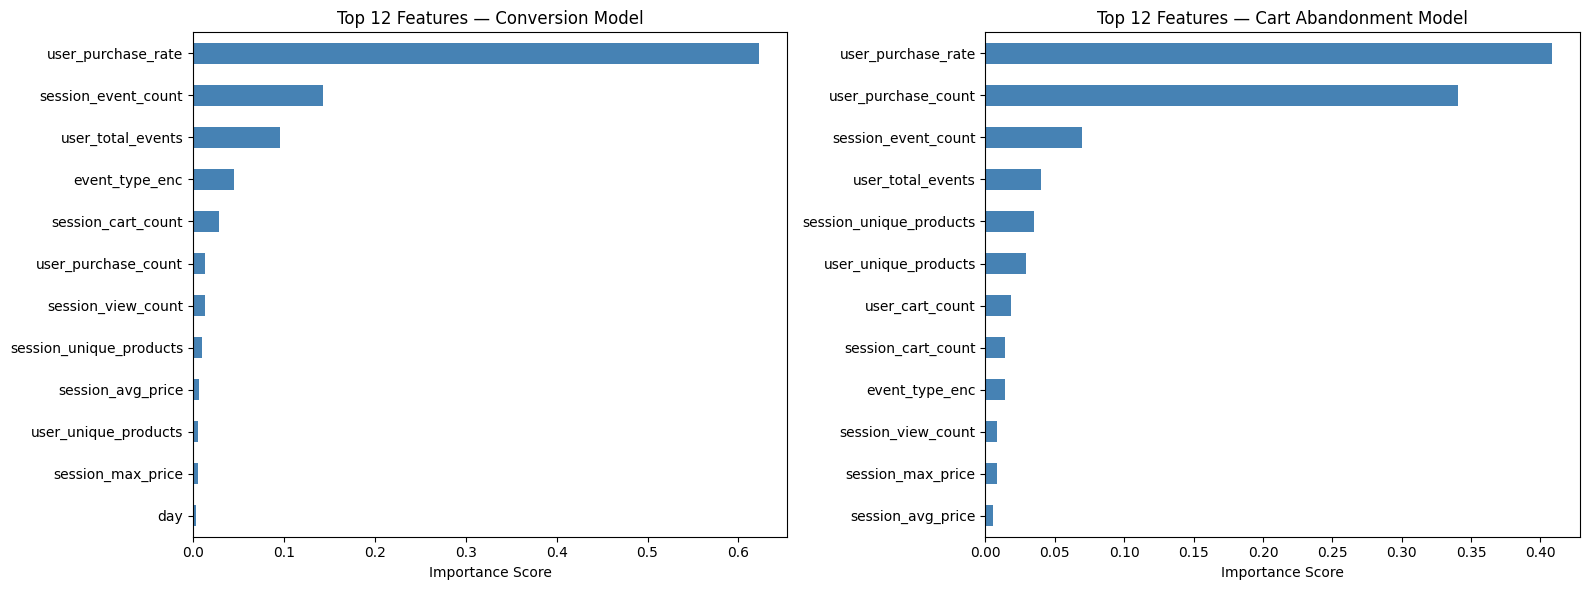

✓ Feature importance plot saved!


In [11]:
feature_cols = [
    'price', 'hour', 'day_of_week', 'day', 'is_weekend',
    'event_type_enc', 'brand_enc',
    'category_level1_enc', 'category_level2_enc',
    'session_event_count', 'session_unique_products',
    'session_view_count', 'session_cart_count',
    'session_avg_price', 'session_max_price',
    'user_total_events', 'user_purchase_count',
    'user_cart_count', 'user_avg_price',
    'user_unique_products', 'user_purchase_rate'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, [
    ("Conversion", conv_model),
    ("Cart Abandonment", cart_model)
]):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp.sort_values().tail(12).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 12 Features — {name} Model')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)  # saves it too
plt.show()
print("✓ Feature importance plot saved!")

In [12]:
import joblib
import os
import json

# Create models folder
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(conv_model, 'models/conversion_model.pkl')
joblib.dump(cart_model, 'models/cart_abandonment_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')

# Save feature columns (Streamlit will need this)
with open('models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# Save label encoder mappings (for brand/category dropdowns in the app)
encoder_maps = {}
cat_cols = ['event_type', 'brand', 'category_level1', 'category_level2']
for col in cat_cols:
    unique_vals = df[col].unique().tolist()
    encoder_maps[col] = unique_vals

with open('models/encoder_maps.json', 'w') as f:
    json.dump(encoder_maps, f)

# Save price stats for input validation in the app
price_stats = {
    'min': float(df['price'].min()),
    'max': float(df['price'].max()),
    'mean': float(df['price'].mean())
}
with open('models/price_stats.json', 'w') as f:
    json.dump(price_stats, f)

print("✓ Models saved!")
print("✓ Feature columns saved!")
print("✓ Encoder maps saved!")
print("✓ Price stats saved!")
print("\nFiles in /models/:")
for file in os.listdir('models'):
    print(f"  - {file}")

✓ Models saved!
✓ Feature columns saved!
✓ Encoder maps saved!
✓ Price stats saved!

Files in /models/:
  - scaler.pkl
  - feature_cols.json
  - cart_abandonment_model.pkl
  - price_stats.json
  - encoder_maps.json
  - conversion_model.pkl


In [13]:
from google.colab import files
import zipfile

# Zip the models folder
with zipfile.ZipFile('models.zip', 'w') as z:
    for file in os.listdir('models'):
        z.write(f'models/{file}')

files.download('models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import os
os.makedirs('ecommerce_app/models', exist_ok=True)
print("✓ Folders created")

✓ Folders created


In [15]:
import shutil

for file in os.listdir('models'):
    shutil.copy(f'models/{file}', f'ecommerce_app/models/{file}')
    print(f"✓ Copied {file}")

✓ Copied scaler.pkl
✓ Copied feature_cols.json
✓ Copied cart_abandonment_model.pkl
✓ Copied price_stats.json
✓ Copied encoder_maps.json
✓ Copied conversion_model.pkl


In [16]:
%%writefile ecommerce_app/requirements.txt
streamlit
scikit-learn
pandas
numpy
joblib
plotly
pyngrok

Writing ecommerce_app/requirements.txt


In [17]:
%%writefile ecommerce_app/app.py
# paste full app.py code here

Writing ecommerce_app/app.py


In [18]:
%%writefile ecommerce_app/app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json
import plotly.graph_objects as go

st.set_page_config(
    page_title="E-Commerce Predictor",
    page_icon="🛍️",
    layout="wide"
)

@st.cache_resource
def load_models():
    conv_model  = joblib.load('models/conversion_model.pkl')
    cart_model  = joblib.load('models/cart_abandonment_model.pkl')
    scaler      = joblib.load('models/scaler.pkl')
    with open('models/feature_cols.json') as f:
        feature_cols = json.load(f)
    with open('models/encoder_maps.json') as f:
        encoder_maps = json.load(f)
    with open('models/price_stats.json') as f:
        price_stats = json.load(f)
    return conv_model, cart_model, scaler, feature_cols, encoder_maps, price_stats

conv_model, cart_model, scaler, feature_cols, encoder_maps, price_stats = load_models()

def encode_label(value, mapping_list):
    if value in mapping_list:
        return mapping_list.index(value)
    return 0

def make_gauge(title, value, color):
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=round(value * 100, 1),
        number={'suffix': '%'},
        title={'text': title, 'font': {'size': 18}},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': color},
            'steps': [
                {'range': [0, 40],  'color': '#d4edda'},
                {'range': [40, 70], 'color': '#fff3cd'},
                {'range': [70, 100],'color': '#f8d7da'},
            ],
        }
    ))
    fig.update_layout(height=280, margin=dict(t=40, b=0, l=20, r=20))
    return fig

st.title("🛍️ E-Commerce Conversion & Cart Abandonment Predictor")
st.markdown("*Cosmetics Store — Powered by ML (Oct 2019 Dataset)*")
st.divider()

st.sidebar.header("📋 Session Inputs")

event_type = st.sidebar.selectbox("Event Type", encoder_maps['event_type'])
brand = st.sidebar.selectbox("Brand", encoder_maps['brand'])
category_level1 = st.sidebar.selectbox("Category Level 1", encoder_maps['category_level1'])
category_level2 = st.sidebar.selectbox("Category Level 2", encoder_maps['category_level2'])
price = st.sidebar.slider(
    "Product Price ($)",
    min_value=float(price_stats['min']),
    max_value=min(float(price_stats['max']), 2000.0),
    value=float(price_stats['mean']),
    step=0.5
)

st.sidebar.subheader("🕐 Time Features")
hour        = st.sidebar.slider("Hour of Day", 0, 23, 14)
day_of_week = st.sidebar.slider("Day of Week (0=Mon, 6=Sun)", 0, 6, 2)
day         = st.sidebar.slider("Day of Month", 1, 31, 15)
is_weekend  = 1 if day_of_week >= 5 else 0

st.sidebar.subheader("📦 Session Stats")
session_event_count      = st.sidebar.number_input("Events in Session", 1, 100, 5)
session_unique_products  = st.sidebar.number_input("Unique Products Viewed", 1, 50, 3)
session_view_count       = st.sidebar.number_input("Views in Session", 0, 100, 4)
session_cart_count       = st.sidebar.number_input("Cart Adds in Session", 0, 20, 1)
session_avg_price        = st.sidebar.number_input("Session Avg Price ($)", 0.0, 2000.0, float(price_stats['mean']))
session_max_price        = st.sidebar.number_input("Session Max Price ($)", 0.0, 5000.0, float(price_stats['mean']) * 1.5)

st.sidebar.subheader("👤 User History")
user_total_events    = st.sidebar.number_input("User Total Events", 1, 5000, 50)
user_purchase_count  = st.sidebar.number_input("User Past Purchases", 0, 500, 3)
user_cart_count      = st.sidebar.number_input("User Cart Events", 0, 1000, 10)
user_avg_price       = st.sidebar.number_input("User Avg Price ($)", 0.0, 2000.0, float(price_stats['mean']))
user_unique_products = st.sidebar.number_input("User Unique Products", 1, 2000, 20)
user_purchase_rate   = user_purchase_count / user_total_events if user_total_events > 0 else 0

if st.sidebar.button("🔮 Predict", use_container_width=True):

    input_data = pd.DataFrame([{
        'price':                   price,
        'hour':                    hour,
        'day_of_week':             day_of_week,
        'day':                     day,
        'is_weekend':              is_weekend,
        'event_type_enc':          encode_label(event_type,      encoder_maps['event_type']),
        'brand_enc':               encode_label(brand,           encoder_maps['brand']),
        'category_level1_enc':     encode_label(category_level1, encoder_maps['category_level1']),
        'category_level2_enc':     encode_label(category_level2, encoder_maps['category_level2']),
        'session_event_count':     session_event_count,
        'session_unique_products': session_unique_products,
        'session_view_count':      session_view_count,
        'session_cart_count':      session_cart_count,
        'session_avg_price':       session_avg_price,
        'session_max_price':       session_max_price,
        'user_total_events':       user_total_events,
        'user_purchase_count':     user_purchase_count,
        'user_cart_count':         user_cart_count,
        'user_avg_price':          user_avg_price,
        'user_unique_products':    user_unique_products,
        'user_purchase_rate':      user_purchase_rate,
    }])

    X_scaled = scaler.transform(input_data[feature_cols])

    conv_prob = conv_model.predict_proba(X_scaled)[0][1]
    cart_prob = cart_model.predict_proba(X_scaled)[0][1]

    col1, col2 = st.columns(2)

    with col1:
        st.plotly_chart(
            make_gauge("🎯 Conversion Probability", conv_prob, "#2196F3"),
            use_container_width=True
        )
        if conv_prob >= 0.7:
            st.success("✅ High likelihood of purchase!")
        elif conv_prob >= 0.4:
            st.warning("⚠️ Moderate — consider a nudge (discount/reminder)")
        else:
            st.error("❌ Low conversion — user likely browsing only")

    with col2:
        st.plotly_chart(
            make_gauge("🛒 Cart Abandonment Risk", cart_prob, "#FF5722"),
            use_container_width=True
        )
        if cart_prob >= 0.7:
            st.error("🚨 High abandonment risk — trigger retention offer!")
        elif cart_prob >= 0.4:
            st.warning("⚠️ Moderate risk — send reminder email")
        else:
            st.success("✅ Low risk — user likely to complete purchase")

    st.divider()
    st.subheader("📊 Prediction Summary")
    summary = pd.DataFrame({
        'Metric': ['Conversion Probability', 'Cart Abandonment Risk', 'Recommended Action'],
        'Result': [
            f"{conv_prob*100:.1f}%",
            f"{cart_prob*100:.1f}%",
            "Send discount" if cart_prob > 0.7 and conv_prob < 0.5
            else "No action needed" if conv_prob > 0.7
            else "Monitor session"
        ]
    })
    st.table(summary)

else:
    st.info("👈 Fill in the session details in the sidebar and click Predict")

Overwriting ecommerce_app/app.py


In [19]:
!pip install streamlit pyngrok -q

from pyngrok import ngrok
import time

!cd ecommerce_app && streamlit run app.py &
time.sleep(5)

public_url = ngrok.connect(8501)
print(f"\n✅ App is live at: {public_url}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.4 MB/s eta 0:00:00


2026-06-02 00:52:53.552 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.178.233:8501

  Stopping...


ERROR:pyngrok.process.ngrok:t=2026-06-02T01:19:39+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-02T01:19:39+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [20]:
# Alternative: cloudflared tunnel
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!pkill -f streamlit 2>/dev/null
import time
time.sleep(2)
!cd ecommerce_app && streamlit run app.py --server.port 8501 &
time.sleep(5)
!./cloudflared tunnel --url http://localhost:8501 &
time.sleep(8)
print("✅ Look above for a URL like: https://xxxx.trycloudflare.com")

^C


2026-06-02 01:20:48.141 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.178.233:8501

  Stopping...
2026-06-02T01:32:10Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-02T01:32:10Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-02T01:32:14Z INF +---------------------------------------

In [21]:
import os, time

# Step 1: Kill existing processes
os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
time.sleep(3)

# Step 2: Download cloudflared
os.system("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared")
os.system("chmod +x cloudflared")

# Step 3: Start Streamlit
os.system("cd ecommerce_app && streamlit run app.py --server.port 8501 &")
time.sleep(6)

# Step 4: Start cloudflare tunnel and capture URL
import subprocess
proc = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(8)

# Step 5: Extract the public URL
output = proc.stderr.read1(4096).decode('utf-8')
for line in output.split('\n'):
    if 'trycloudflare.com' in line:
        url = line.split('|')[-1].strip() if '|' in line else line.strip()
        print(f"\n✅ Your app URL: {url}")
        break
else:
    print("Still starting... run this in a new cell:")
    print("!./cloudflared tunnel --url http://localhost:8501")


✅ Your app URL: 2026-06-02T01:35:09Z INF Requesting new quick Tunnel on trycloudflare.com...


In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-06-02T01:37:19Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-02T01:37:19Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-02T01:37:22Z INF +--------------------------------------------------------------------------------------------+
2026-06-02T01:37:22Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-02T01:37:22Z INF |  https://hydraulic-statewide-tuning-mls.trycloudflare.